In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

This notebook will be for tomatoes, since their pricing is a lot more difficult

In [7]:
DATA_DIR = Path("TUTORIAL_ROUND_1")

# Load prices CSVs
prices_files = sorted(DATA_DIR.glob("prices_*.csv"))
prices_frames = [pd.read_csv(f, sep=";").assign(source_file=f.name) for f in prices_files]
prices_df = pd.concat(prices_frames, ignore_index=True)

# Load trades CSVs
trades_files = sorted(DATA_DIR.glob("trades_*.csv"))
trades_frames = [pd.read_csv(f, sep=";").assign(source_file=f.name) for f in trades_files]
trades_df = pd.concat(trades_frames, ignore_index=True)

# Filter for TOMATOES in prices
tomato_prices = prices_df[prices_df["product"] == "TOMATOES"]

# Filter for TOMATOES in trades
tomato_trades = trades_df[trades_df["symbol"] == "TOMATOES"]



,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,source_file
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0,prices_round_0_day_-1.csv
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0,prices_round_0_day_-1.csv
5,-1,200,TOMATOES,5000,10,4999,20,NaN,NaN,5013,10,5015,20,NaN,NaN,5006.5,0.0,prices_round_0_day_-1.csv
6,-1,300,TOMATOES,5000,9,4999,21,NaN,NaN,5014,9,5015,21,NaN,NaN,5007.0,0.0,prices_round_0_day_-1.csv
8,-1,400,TOMATOES,5000,5,4999,20,NaN,NaN,5014,5,5015,20,NaN,NaN,5007.0,0.0,prices_round_0_day_-1.csv


separate into tomato pricing + tomato trades df

In [ ]:
tomato_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,source_file
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0,prices_round_0_day_-1.csv
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0,prices_round_0_day_-1.csv
5,-1,200,TOMATOES,5000,10,4999,20,NaN,NaN,5013,10,5015,20,NaN,NaN,5006.5,0.0,prices_round_0_day_-1.csv
6,-1,300,TOMATOES,5000,9,4999,21,NaN,NaN,5014,9,5015,21,NaN,NaN,5007.0,0.0,prices_round_0_day_-1.csv
8,-1,400,TOMATOES,5000,5,4999,20,NaN,NaN,5014,5,5015,20,NaN,NaN,5007.0,0.0,prices_round_0_day_-1.csv


In [12]:
tomato_trades.head()

,timestamp,buyer,seller,symbol,currency,price,quantity,source_file
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2,trades_round_0_day_-1.csv
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4,trades_round_0_day_-1.csv
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5,trades_round_0_day_-1.csv
5,9900,NaN,NaN,TOMATOES,XIRECS,5000.0,4,trades_round_0_day_-1.csv
6,16400,NaN,NaN,TOMATOES,XIRECS,4996.0,2,trades_round_0_day_-1.csv


Find out 

In [13]:
tomato_trades.columns

Index(['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity', 'source_file'],
      dtype='object')

In [14]:
tomato_prices.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss',
       'source_file'],
      dtype='object')

In [15]:
# Compute tomato-specific order book features on the price data
tomato_prices = tomato_prices.sort_values("timestamp").reset_index(drop=True)
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]

tomato_prices[volume_cols] = tomato_prices[volume_cols].fillna(0)

# Spread
tomato_prices["spread"] = tomato_prices["ask_price_1"] - tomato_prices["bid_price_1"]

# Depth
tomato_prices["bid_depth"] = (
    tomato_prices["bid_volume_1"] +
    tomato_prices["bid_volume_2"] +
    tomato_prices["bid_volume_3"]
)
tomato_prices["ask_depth"] = (
    tomato_prices["ask_volume_1"] +
    tomato_prices["ask_volume_2"] +
    tomato_prices["ask_volume_3"]
)

# Imbalance
tomato_prices["imbalance"] = (
    tomato_prices["bid_depth"] - tomato_prices["ask_depth"]
) / (
    tomato_prices["bid_depth"] + tomato_prices["ask_depth"]
)

# Mid-price returns
tomato_prices["mid_return"] = tomato_prices["mid_price"].diff()

# Rolling volatility (window=50 ticks)
tomato_prices["volatility"] = tomato_prices["mid_return"].rolling(50).std()

# Microprice
tomato_prices["microprice"] = (
    tomato_prices["bid_price_1"] * tomato_prices["ask_volume_1"] +
    tomato_prices["ask_price_1"] * tomato_prices["bid_volume_1"]
) / (
    tomato_prices["bid_volume_1"] + tomato_prices["ask_volume_1"]
)

tomato_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,mid_price,profit_and_loss,source_file,spread,bid_depth,ask_depth,imbalance,mid_return,volatility,microprice
0,-1,0,TOMATOES,4999,5,4998,15,NaN,0.0,5013,...,5006.0,0.0,prices_round_0_day_-1.csv,14,20.0,20.0,0.000000,NaN,NaN,5006.00
1,-2,0,TOMATOES,4993,7,4992,17,NaN,0.0,5007,...,5000.0,0.0,prices_round_0_day_-2.csv,14,24.0,24.0,0.000000,-6.0,NaN,5000.00
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,...,5002.5,0.0,prices_round_0_day_-2.csv,9,28.0,23.0,0.098039,2.5,NaN,5001.75
3,-1,100,TOMATOES,5000,8,4998,21,NaN,0.0,5013,...,5006.5,0.0,prices_round_0_day_-1.csv,13,29.0,29.0,0.000000,4.0,NaN,5006.50
4,-1,200,TOMATOES,5000,10,4999,20,NaN,0.0,5013,...,5006.5,0.0,prices_round_0_day_-1.csv,13,30.0,30.0,0.000000,0.0,NaN,5006.50


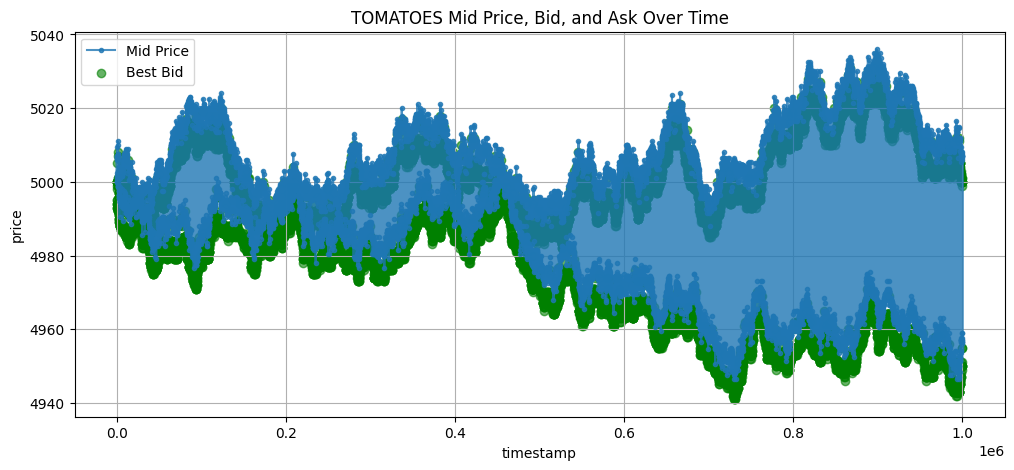

In [ ]:
plt.figure(figsize=(12, 5))

# Midprice line
plt.plot(
    tomato_prices["timestamp"],
    tomato_prices["mid_price"],
    marker=".",
    alpha=0.8,
    label="Mid Price"
)

# # Best bid points
# plt.scatter(
#     tomato_prices["timestamp"],
#     tomato_prices["bid_price_1"],
#     alpha=0.6,
#     color="green",
#     label="Best Bid"
# )

# # Best ask points
# plt.scatter(
#     tomato_prices["timestamp"],
#     tomato_prices["ask_price_1"],
#     alpha=0.6,
#     color="purple",
#     label="Best Ask"
# )

plt.title("TOMATOES Mid Price, Bid, and Ask Over Time")
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()

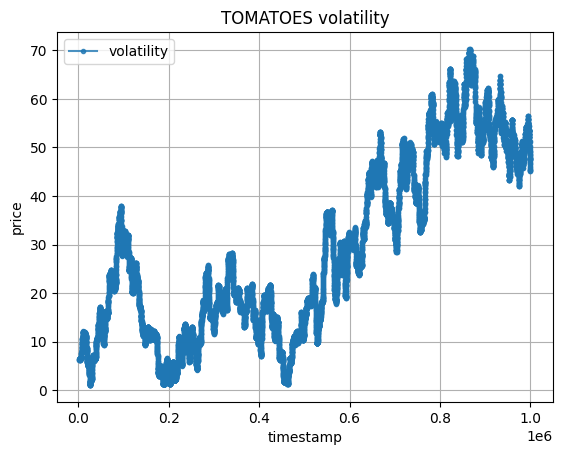

In [27]:
term = "volatility"

plt.title("TOMATOES " + term)
plt.plot(
    tomato_prices["timestamp"],
    tomato_prices[term],
    marker=".",
    alpha=0.8,
    label=term, 
)
plt.xlabel("timestamp")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()